In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import matplotlib.pyplot
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import cv2
image_folder_path = '/content/drive/MyDrive/DS Kuliah/deteksi Plat Nomor/dataset'

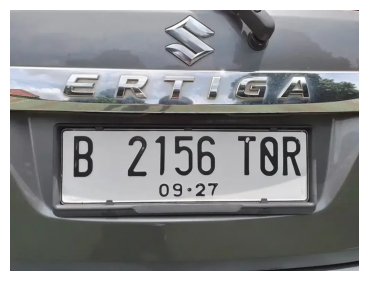

In [4]:
image_files = [os.path.join(image_folder_path, file) for file in os.listdir(image_folder_path)]
X = [np.array(Image.open(image)) for image in image_files]
plt.figure(figsize=(30, 40))
for i in range(min(17, len(X))):
    plt.subplot(10, 5, i + 1)
    plt.axis('off')
    plt.imshow(X[i])
plt.show()

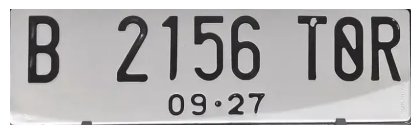

In [5]:
def pakai_canny(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]
    for contour in contours:
        epsilon = 0.018 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            plate_img = image[y:y+h, x:x+w]
            return plate_img

    return None

plt.figure(figsize=(30, 40))
for i in range(min(17, len(X))):
    image_with_box = pakai_canny(X[i].copy())
    plt.subplot(10, 5, i + 1)
    plt.axis('off')
    plt.imshow(cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB))
plt.show()

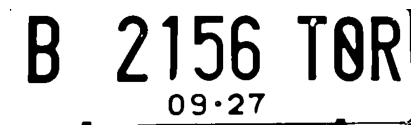

In [10]:
def pakai_otsu(plate_img):
    # Konversi ke grayscale
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

    # Gunakan Gaussian Blur untuk mengurangi noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Thresholding Otsu (Inverse agar teks jadi putih di atas hitam atau sebaliknya)
    # Kita buat teks berwarna hitam di atas latar putih bersih
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return thresh

plt.figure(figsize=(30, 40))
for i in range(len(X)):
    plate_img = pakai_canny(X[i].copy())
    if plate_img is not None:
        text_img = pakai_otsu(plate_img)
        plt.subplot(10, 5, i + 1)
        plt.axis('off')
        plt.imshow(text_img, cmap='gray')
plt.show()

In [7]:
!apt-get install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


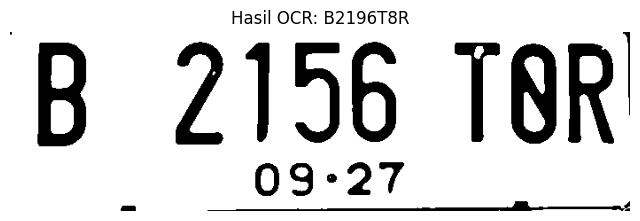

Plat Nomor Terdeteksi: B2196T8R


In [11]:
import pytesseract
import numpy as np

def baca_plat(thresh_img):
    # Resize gambar agar karakter lebih besar (3x lipat)
    height, width = thresh_img.shape[:2]
    resized = cv2.resize(thresh_img, (width * 3, height * 3), interpolation=cv2.INTER_LINEAR)

    # Invert jika perlu (Tesseract suka teks hitam di atas background putih)
    # Kita cek rata-rata warna, jika dominan hitam, kita balik
    if np.mean(resized) < 127:
        resized = cv2.bitwise_not(resized)

    # Konfigurasi: psm 7 (single line)
    config = '--psm 7 -c tessedit_char_whitelist=0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    text = pytesseract.image_to_string(resized, config=config)
    return text.strip()

# Uji coba ulang dengan pemrosesan baru
for i in range(len(X)):
    plate_img = pakai_canny(X[i].copy())
    if plate_img is not None:
        text_img = pakai_otsu(plate_img)
        hasil_baca = baca_plat(text_img)

        plt.figure(figsize=(8, 3))
        plt.imshow(text_img, cmap='gray')
        plt.title(f'Hasil OCR: {hasil_baca}')
        plt.axis('off')
        plt.show()
        print(f'Plat Nomor Terdeteksi: {hasil_baca}')